# Paper 1 — canonical figures & tables (2026-07-23)
Everything renders from `outputs/lexicon/paper1_figdata.json` (assembled from the prereg result artifacts; see `latex/paper-1__metric-codability/FIGURES.md` for the canon spec). PNGs are written to `latex/paper-1__metric-codability/figs/`.

- **Fig 1** (L0→R3 subtree) is native TikZ in `main.tex` — its data dict is shown at the bottom.
- Palette validated with the dataviz six-checks validator: blue `#2a78d6` (human classes), orange `#eb6834` (LLM families).

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT='/Users/spangher/Projects/stanford-research/norm-research'
D=json.load(open(f'{ROOT}/outputs/lexicon/paper1_figdata.json'))
FIGS=f'{ROOT}/latex/paper-1__metric-codability/figs'
os.makedirs(FIGS,exist_ok=True)
BLUE,ORANGE,INK,MUTED='#2a78d6','#eb6834','#0b0b0b','#52514e'
plt.rcParams.update({'font.size':9,'axes.edgecolor':MUTED,'axes.linewidth':.6,
  'xtick.color':MUTED,'ytick.color':MUTED,'axes.labelcolor':INK,'text.color':INK})
print('tasks:',len(D['table1']))

tasks: 11


## Table 1 — inventory size at each level of the hierarchy, per task
Closed head, open tail: R2/R3 are small and saturated; L0/R1 are large and productive (L0 Good–Turing missing mass shown).

In [2]:
t1=pd.DataFrame(D['table1']).T[['L0','R1','R2','R3','L0_mm']]
t1.columns=['L0 forms','R1 constructs','R2 themes','R3 categories','L0 GT missing mass']
t1=t1.sort_index()
t1

,L0 forms,R1 constructs,R2 themes,R3 categories,L0 GT missing mass
code-review,8118.0,4489.0,42.0,9.0,0.5210
creative-writing,2850.0,1120.0,56.0,9.0,0.4236
grant-funding,1647.0,408.0,45.0,6.0,0.4591
humor,3363.0,1569.0,50.0,9.0,0.4260
legal-outcome-prediction,2262.0,657.0,44.0,9.0,0.5577
math-stackexchange,3337.0,820.0,40.0,7.0,0.4874
news-homepages,1598.0,844.0,45.0,8.0,0.3948
notice-and-comment,2034.0,555.0,38.0,7.0,0.5899
patents,2397.0,949.0,52.0,8.0,0.4431
peer-review,1859.0,318.0,44.0,7.0,0.4315


## Table 2 — register (raw judged formality 1–7) by rule-writer class × task
PREREG-10R data (9{,}292 gated judgments). Reversed domains (press-releases, news) shown, not hidden. Compare raw formality/latinate — never pooled-z heights — across runs.

In [3]:
rows={}
for task,cl in D['table2'].items():
    rows[task]={c:cl[c]['formality'] for c in ('community_rule','individual_lay','official') if c in cl}
t2=pd.DataFrame(rows).T.rename(columns={'community_rule':'community rules',
    'individual_lay':'individual lay','official':'official'}).sort_index()
t2

,community rules,individual lay,official
code-review,3.36,3.68,NaN
creative-writing,3.14,3.30,4.73
grant-funding,3.36,3.70,NaN
humor,2.75,3.08,3.83
legal-outcome-prediction,3.60,3.55,NaN
math-stackexchange,3.23,3.70,5.42
news-homepages,3.62,3.57,4.17
notice-and-comment,3.64,3.79,NaN
patents,4.14,3.71,NaN
peer-review,3.84,3.91,NaN


## Fig 2 — LLMs speak the official register
Mean judged formality of criterion names by speaker class; every LLM family sits at or above the official class.

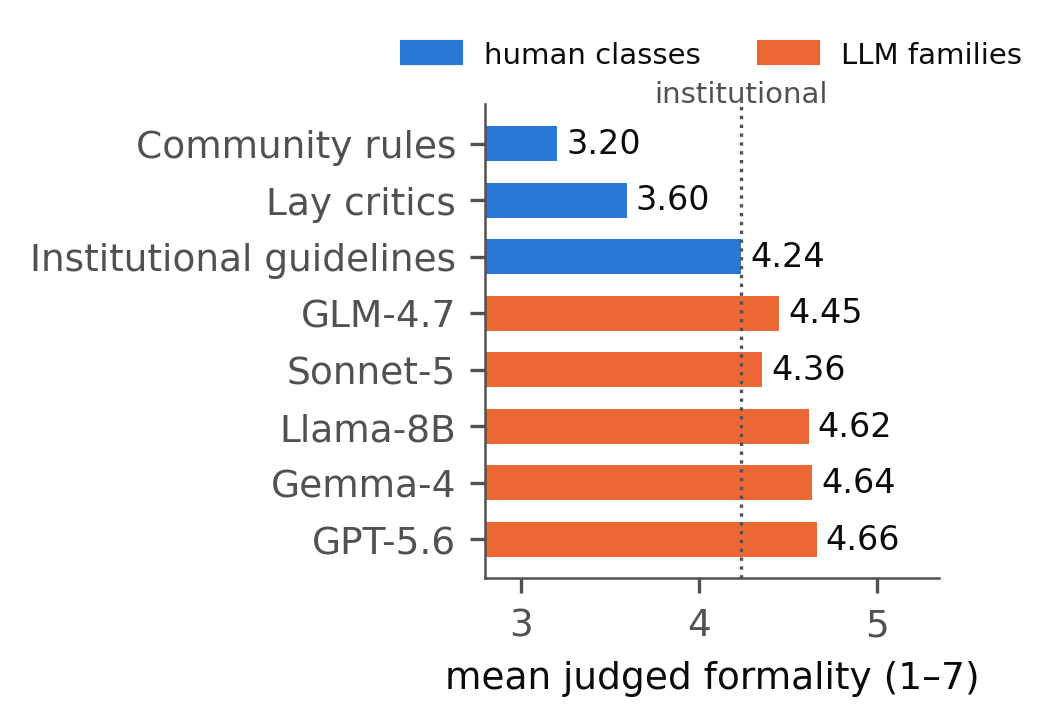

In [4]:
f2=D['fig2_formality']
order=[('community_rule','Community rules'),('individual_lay','Lay critics'),
       ('official','Institutional guidelines'),('llm_glm','GLM-4.7'),('llm_claude_raw','Sonnet-5'),
       ('llm_llama8b_raw','Llama-8B'),('llm_gemma4_raw','Gemma-4'),('llm_gpt56','GPT-5.6')]
labels=[l for _,l in order]; vals=[f2[k] for k,_ in order]
cols=[BLUE]*3+[ORANGE]*5
fig,ax=plt.subplots(figsize=(3.3,2.5),dpi=300)
y=np.arange(len(order))
ax.barh(y,vals,color=cols,height=.62)
for yi,v in zip(y,vals): ax.text(v+.05,yi,f'{v:.2f}',va='center',fontsize=8,color=INK)
ax.axvline(f2['official'],color=MUTED,lw=.8,ls=':')
ax.text(f2['official'],-0.62,'institutional',color=MUTED,fontsize=7,ha='center',va='bottom')
ax.set_yticks(y,labels); ax.invert_yaxis()
ax.set_xlim(2.8,5.35); ax.set_xlabel('mean judged formality (1–7)')
ax.spines[['top','right']].set_visible(False)
import matplotlib.patches as mp
ax.legend(handles=[mp.Patch(color=BLUE,label='human classes'),mp.Patch(color=ORANGE,label='LLM families')],
          frameon=False,fontsize=7,loc='lower center',bbox_to_anchor=(0.5,1.02),ncol=2)
plt.tight_layout(); plt.savefig(f'{FIGS}/fig2_register_barplot.png',bbox_inches='tight'); plt.show()

## Fig 3 — the name does the work
(a) per-family name-swap: within-name rank reliability (blue) vs between-name agreement (orange); the gap is Δ. (b) name swap vs full-scaffold paraphrase.

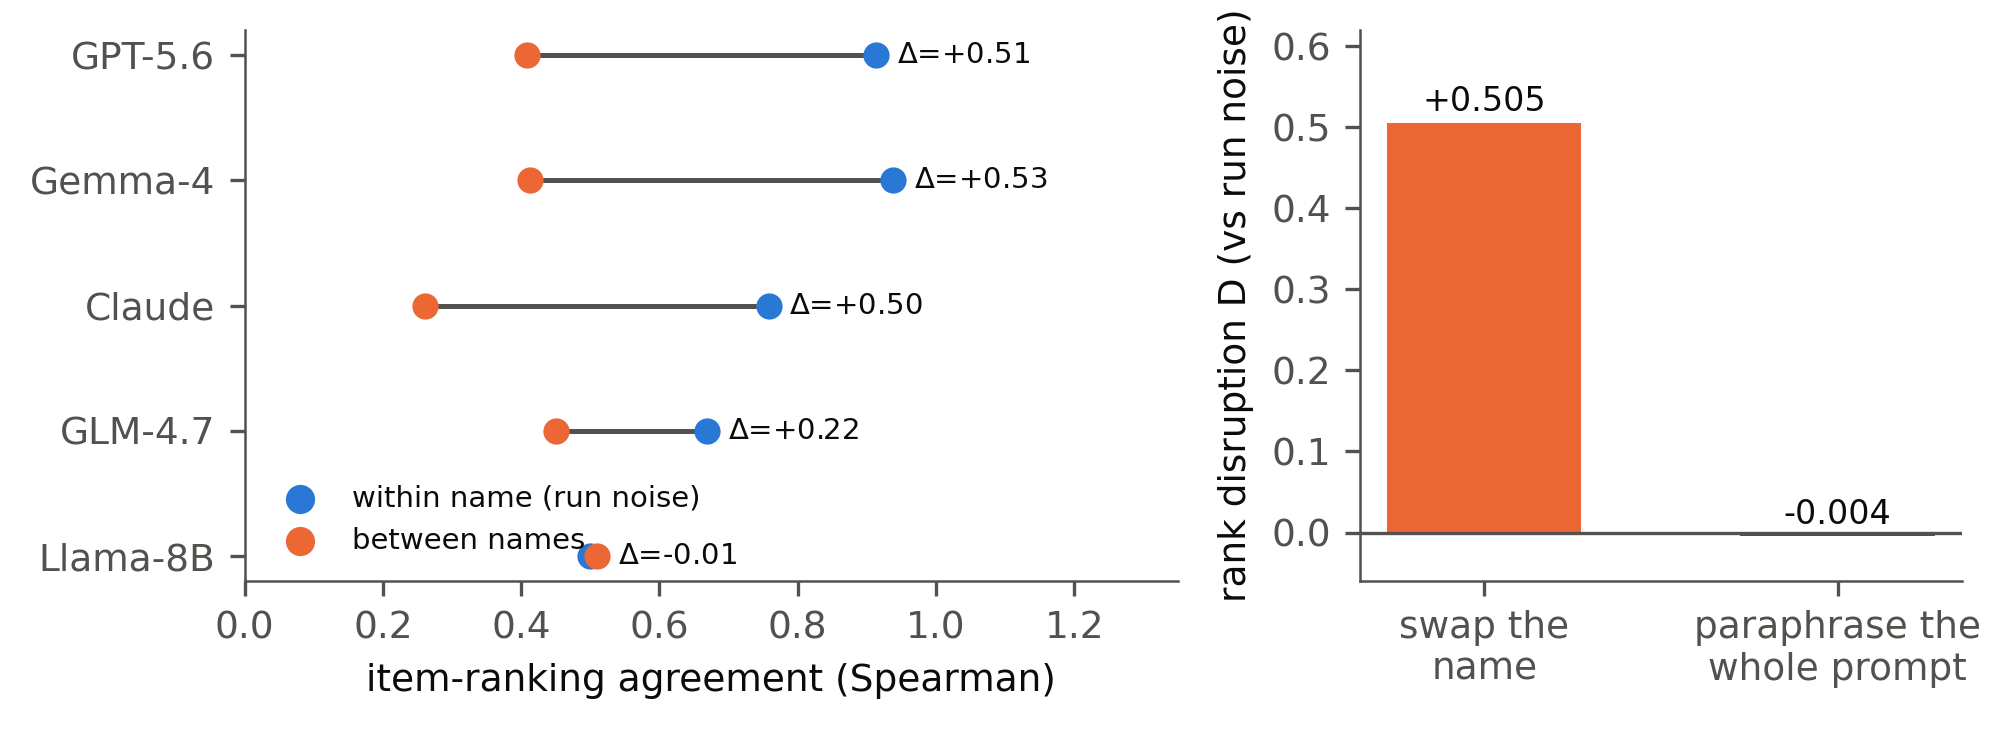

In [5]:
fam=D['fig3a_families']
names=['GPT-5.6','Gemma-4','Claude','GLM-4.7','Llama-8B']
fig,(a,b)=plt.subplots(1,2,figsize=(6.8,2.5),dpi=300,gridspec_kw={'width_ratios':[1.55,1]})
y=np.arange(len(names))
for yi,n in zip(y,names):
    w=fam[n]['within']; btw=w-fam[n]['delta']
    a.plot([btw,w],[yi,yi],color=MUTED,lw=1.2,zorder=1)
    a.scatter([w],[yi],color=BLUE,s=28,zorder=2)
    a.scatter([btw],[yi],color=ORANGE,s=28,zorder=2)
    a.text(max(w,btw)+.03,yi,f"$\\Delta$={fam[n]['delta']:+.2f}",va='center',fontsize=7,color=INK)
a.set_yticks(y,names); a.invert_yaxis(); a.set_xlim(0,1.35)
a.set_xlabel('item-ranking agreement (Spearman)')
a.spines[['top','right']].set_visible(False)
a.scatter([],[],color=BLUE,label='within name (run noise)'); a.scatter([],[],color=ORANGE,label='between names')
a.legend(frameon=False,fontsize=7,loc='lower left')
nb_=D['fig3b_name_vs_scaffold']
b.bar([0,1],[nb_['D_name'],nb_['D_scaffold']],color=[ORANGE,MUTED],width=.55)
b.set_xticks([0,1],['swap the\nname','paraphrase the\nwhole prompt'])
for x,v in [(0,nb_['D_name']),(1,nb_['D_scaffold'])]:
    b.text(x,v+.015,f'{v:+.3f}',ha='center',fontsize=8,color=INK)
b.axhline(0,color=MUTED,lw=.8)
b.set_ylabel('rank disruption D (vs run noise)')
b.set_ylim(-.06,.62); b.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{FIGS}/fig3_name_effects.png',bbox_inches='tight'); plt.show()

## Table 3 — top informal-AUC vs formal-AUC metrics (PREREG-15, silver labels)
Largest CI-clean per-metric form effects, each side. Register does not predict the winner (44/44 overall); polarity does (PREREG-17).

In [6]:
rows=[]
for side in ('low_wins','high_wins'):
    for r in D['table3'][side]:
        rows.append({'winner':'informal form' if side=='low_wins' else 'formal form',
                     'metric':r['mid'],'informal form':r['low'],'formal form':r['high'],
                     'AUC(informal)':r['auc_low'],'AUC(formal)':r['auc_high'],'ΔAUC':r['dauc']})
pd.set_option('display.max_colwidth',60)
pd.DataFrame(rows)

,winner,metric,informal form,formal form,AUC(informal),AUC(formal),ΔAUC
0,informal form,a32,Does the joke land at the target audience's 'clean' level?,Use of crude/sexual/scatological material,0.8375,0.3362,0.5012
1,informal form,a0,"Punch up, not down",Working Rubric — Presence of the target,0.9175,0.4175,0.5000
2,informal form,a36,Keep it simple; don't overthink,Specificity and lyricism in writing,0.9413,0.4525,0.4888
3,informal form,a142,Storytelling with long setups and twist endings,Exclusion — Pure congruity (predictable punchline),0.5700,0.1037,0.4662
4,informal form,a196,Strong button (sketch),Credits interrupted by stingers or extra scenes (stinger...,0.9525,0.5000,0.4525
5,formal form,a64,hack / hacky / comic's clichés (anti-pattern),Originality (surprise effect),0.1013,0.8688,-0.7675
6,formal form,a118,Rule 12: Be brutal,Economy of language — eliminate unnecessary words,0.2362,0.9625,-0.7263
7,formal form,a2,Use of humor / comedic tone,Humor / comedic effectiveness,0.5062,1.0000,-0.4938
8,formal form,a50,You don't have to be funny all the time,Humor quotient / entertainment vs. analysis balance,0.3588,0.7550,-0.3962
9,formal form,a86,Failure mode: R2 too hard to find,Object is a perceived incongruity,0.2662,0.6125,-0.3463


## Fig 1 data — the L0→R3 subtree (rendered natively in TikZ in `main.tex`)
Real subtree under humor R3 category **C1 'Comic Structure & the Surprise Turn'**; L0 leaves carry judged formality (color), etymological stratum, metaphoricity.

In [7]:
tree={'R3':'C1 Comic Structure & the Surprise Turn','themes':[
 {'R2':'T01 Setup–Punchline Mechanics','R1':'two-part joke structure (humor_R1_g316)',
  'L0':[('two-part structure',4,'mixed',None),('structural innovation',6,'latinate',0)]},
 {'R2':'T02 Surprise & Incongruity','R1':"the recognition ('get-it') moment (humor_R1_g306)",
  'L0':[('get it moment',2,'mixed',1),('succession of confusion and clearness',4,'mixed',0),
        ('anagnorisi',7,'greek',None)]},
 {'R2':'T03 Misdirection & Double-Meaning','R1':'planted incongruous detail (humor_R1_g351)',
  'L0':[('first unusual thing',3,'mixed',0),('heightening round 2',3,'mixed',1),
        ('unnecessary detail',4,'latinate',0)]}]}
print(json.dumps(tree,indent=1))

{
 "R3": "C1 Comic Structure & the Surprise Turn",
 "themes": [
  {
   "R2": "T01 Setup\u2013Punchline Mechanics",
   "R1": "two-part joke structure (humor_R1_g316)",
   "L0": [
    [
     "two-part structure",
     4,
     "mixed",
     null
    ],
    [
     "structural innovation",
     6,
     "latinate",
     0
    ]
   ]
  },
  {
   "R2": "T02 Surprise & Incongruity",
   "R1": "the recognition ('get-it') moment (humor_R1_g306)",
   "L0": [
    [
     "get it moment",
     2,
     "mixed",
     1
    ],
    [
     "succession of confusion and clearness",
     4,
     "mixed",
     0
    ],
    [
     "anagnorisi",
     7,
     "greek",
     null
    ]
   ]
  },
  {
   "R2": "T03 Misdirection & Double-Meaning",
   "R1": "planted incongruous detail (humor_R1_g351)",
   "L0": [
    [
     "first unusual thing",
     3,
     "mixed",
     0
    ],
    [
     "heightening round 2",
     3,
     "mixed",
     1
    ],
    [
     "unnecessary detail",
     4,
     "latinate",
     0
    

## Fig — norm age: perennial vs emerging norms per task
Per task: the 3 R2 aspects with the *oldest* earliest source (perennial) and the 3 newest emerging aspects (median source year ≥2022, ≥3 sources). Bars span earliest→latest source year; ticks are individual sources. Data: `outputs/r2_attr_labeling/agg/r2_aspect_year_mentions_distinct_sources.parquet` (year confidence ≥2 filter applied upstream).

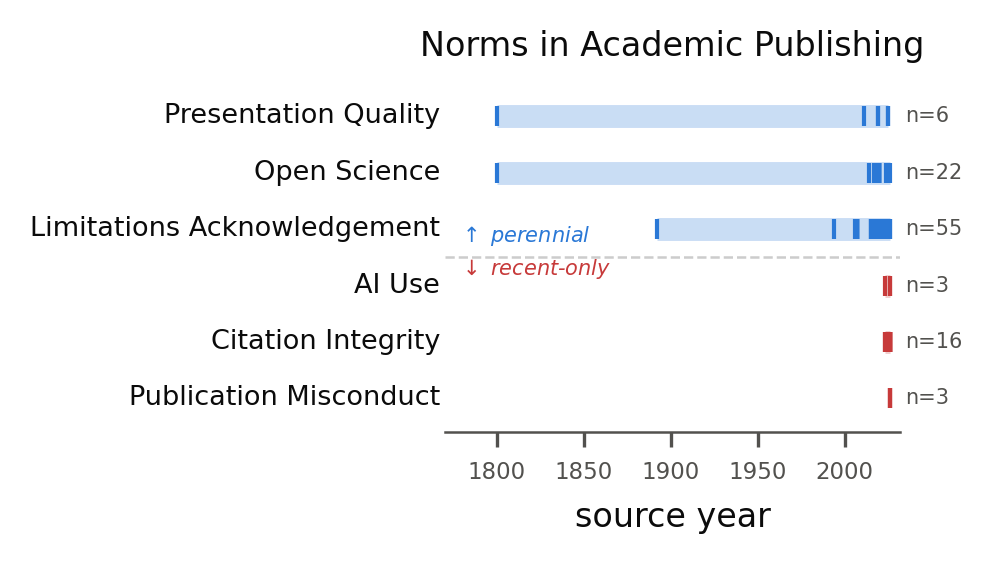

In [8]:

mentions=pd.read_parquet(f'{ROOT}/outputs/r2_attr_labeling/agg/r2_aspect_year_mentions_distinct_sources.parquet')
# drop misdated republished classics (Gutenberg pages dated by fetch, not work)
mentions=mentions[~(mentions.source_file.str.contains('gutenberg',case=False)&(mentions.year>1990))]
# merge sibling aspects by 2-word name stem (taxonomy fragments old concerns)
mentions['stem']=mentions.aspect_name.str.split(r' and |, |: ').str[0].str.split().str[:2].str.join(' ')
RED='#c73a3a'
GEN={'code-review':'Software Code','creative-writing':'Creative Writing','grant-funding':'Grant Proposals',
 'humor':'Humor','legal-outcome-prediction':'Legal Arguments','math-stackexchange':'Math',
 'news-homepages':'Journalism','notice-and-comment':'Regulatory Comments','patents':'Patents',
 'peer-review':'Academic Articles','press-releases':'Press Releases'}
import re
def short(nm,maxw=2):
    if 'Figures and Tables' in nm: return 'Presentation Quality'
    seg=re.split(r', |: |—|/',nm)[0].strip()
    first=re.split(r' and ',seg)[0].strip()
    if len(first.split())==1 and ' and ' in seg:
        return ' & '.join(x.strip() for x in seg.split(' and ')[:2])
    w=first.split()
    return ' '.join(w[:3]) if len(' '.join(w[:2]))<7 else ' '.join(w[:maxw])
X0,X1,XB,XBRK=1418,2032,1432,1458
def yfmt(y): return f'{abs(int(y))} BCE' if y<0 else str(int(y))
def norm_age_panel(ax,task,label_fs=7):
    df=mentions[mentions.task==task]
    stats=df.groupby('stem').agg(aspect_name=('aspect_name','first'),**{'min':('year','min'),'max':('year','max'),'median':('year','median'),'count':('year','count')}).reset_index()
    per=stats[stats['count']>=5].nsmallest(3,'min')
    emer=stats[(stats['median']>=2022)&(stats['count']>=3)&(stats['min']>=2010)].nlargest(3,'median')
    if not len(emer): emer=stats.nlargest(3,'median').head(3)
    allmin=min(list(per['min'])+list(emer['min'])) if len(per) else 1500
    ancient=allmin<1500
    x0 = 1418 if ancient else int((max(allmin,1500)//50)*50)-30
    x1 = 2032
    yy=0; has_ancient=False
    for grp,col in ((per,BLUE),(emer,RED)):
        for r in grp.itertuples():
            ys=df[df.stem==r.stem]['year']
            lo=max(r.min,1500) if ancient else r.min
            ax.hlines(-yy,lo,r.max,color=col,lw=5.5,alpha=.25)
            ax.plot(ys[ys>=(1500 if ancient else x0)],[-yy]*int((ys>=(1500 if ancient else x0)).sum()),'|',color=col,ms=5,mew=1.0)
            if r.min<1500:
                has_ancient=True
                ax.plot([XB,XBRK-8],[-yy,-yy],ls=':',color=col,lw=1.0)
                ax.plot([XB],[-yy],'o',mfc='none',mec=col,ms=4)
                ax.text(XB,-yy+0.34,yfmt(r.min),fontsize=label_fs-1.5,color=col,style='italic',ha='left')
            ax.text(-0.01,-yy,short(r.aspect_name),transform=ax.get_yaxis_transform(),
                    ha='right',va='center',fontsize=label_fs)
            ax.text(1.01,-yy,f'n={r.count}',transform=ax.get_yaxis_transform(),ha='left',va='center',
                    fontsize=label_fs-1.5,color=MUTED)
            yy+=1
        if col is BLUE:
            ax.axhline(-yy+.5,color='#cccccc',lw=.6,ls='--')
            ax.text(.03,-yy+.78,r'$\uparrow$ perennial',transform=ax.get_yaxis_transform(),ha='left',
                    fontsize=label_fs-1.5,color=BLUE,style='italic')
            ax.text(.03,-yy+.18,r'$\downarrow$ recent-only',transform=ax.get_yaxis_transform(),ha='left',
                    fontsize=label_fs-1.5,color=RED,style='italic')
    ax.set_xlim(x0,x1); ax.set_ylim(-yy+.4,.85)
    ax.set_yticks([])
    ax.set_xticks([1500,1700,1900] if ancient else [t for t in (1800,1850,1900,1950,2000) if t>x0+10])
    ax.tick_params(labelsize=label_fs-1)
    ax.spines[['top','right','left']].set_visible(False)
    # axis break marks on the bottom spine (only when ancient leaders exist)
    for dx in ((-4,4) if ancient else ()):
        ax.plot([XBRK+dx-3,XBRK+dx+3],[ax.get_ylim()[0]]*2,color='white',lw=3,clip_on=False,zorder=4)
        ax.plot([XBRK+dx-4,XBRK+dx+4],[ax.get_ylim()[0]-.12,ax.get_ylim()[0]+.12],
                color=MUTED,lw=.8,clip_on=False,zorder=5)
    ax.set_title(GEN[task],fontsize=label_fs+1.5,color=INK,pad=2)
fig,ax=plt.subplots(figsize=(3.4,1.95),dpi=300)
norm_age_panel(ax,'peer-review',label_fs=6.5)
ax.set_title('Norms in Academic Publishing',fontsize=8,color=INK,pad=3)
ax.set_xlabel('source year',fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIGS}/fig_norm_age_main.png',bbox_inches='tight'); plt.show()


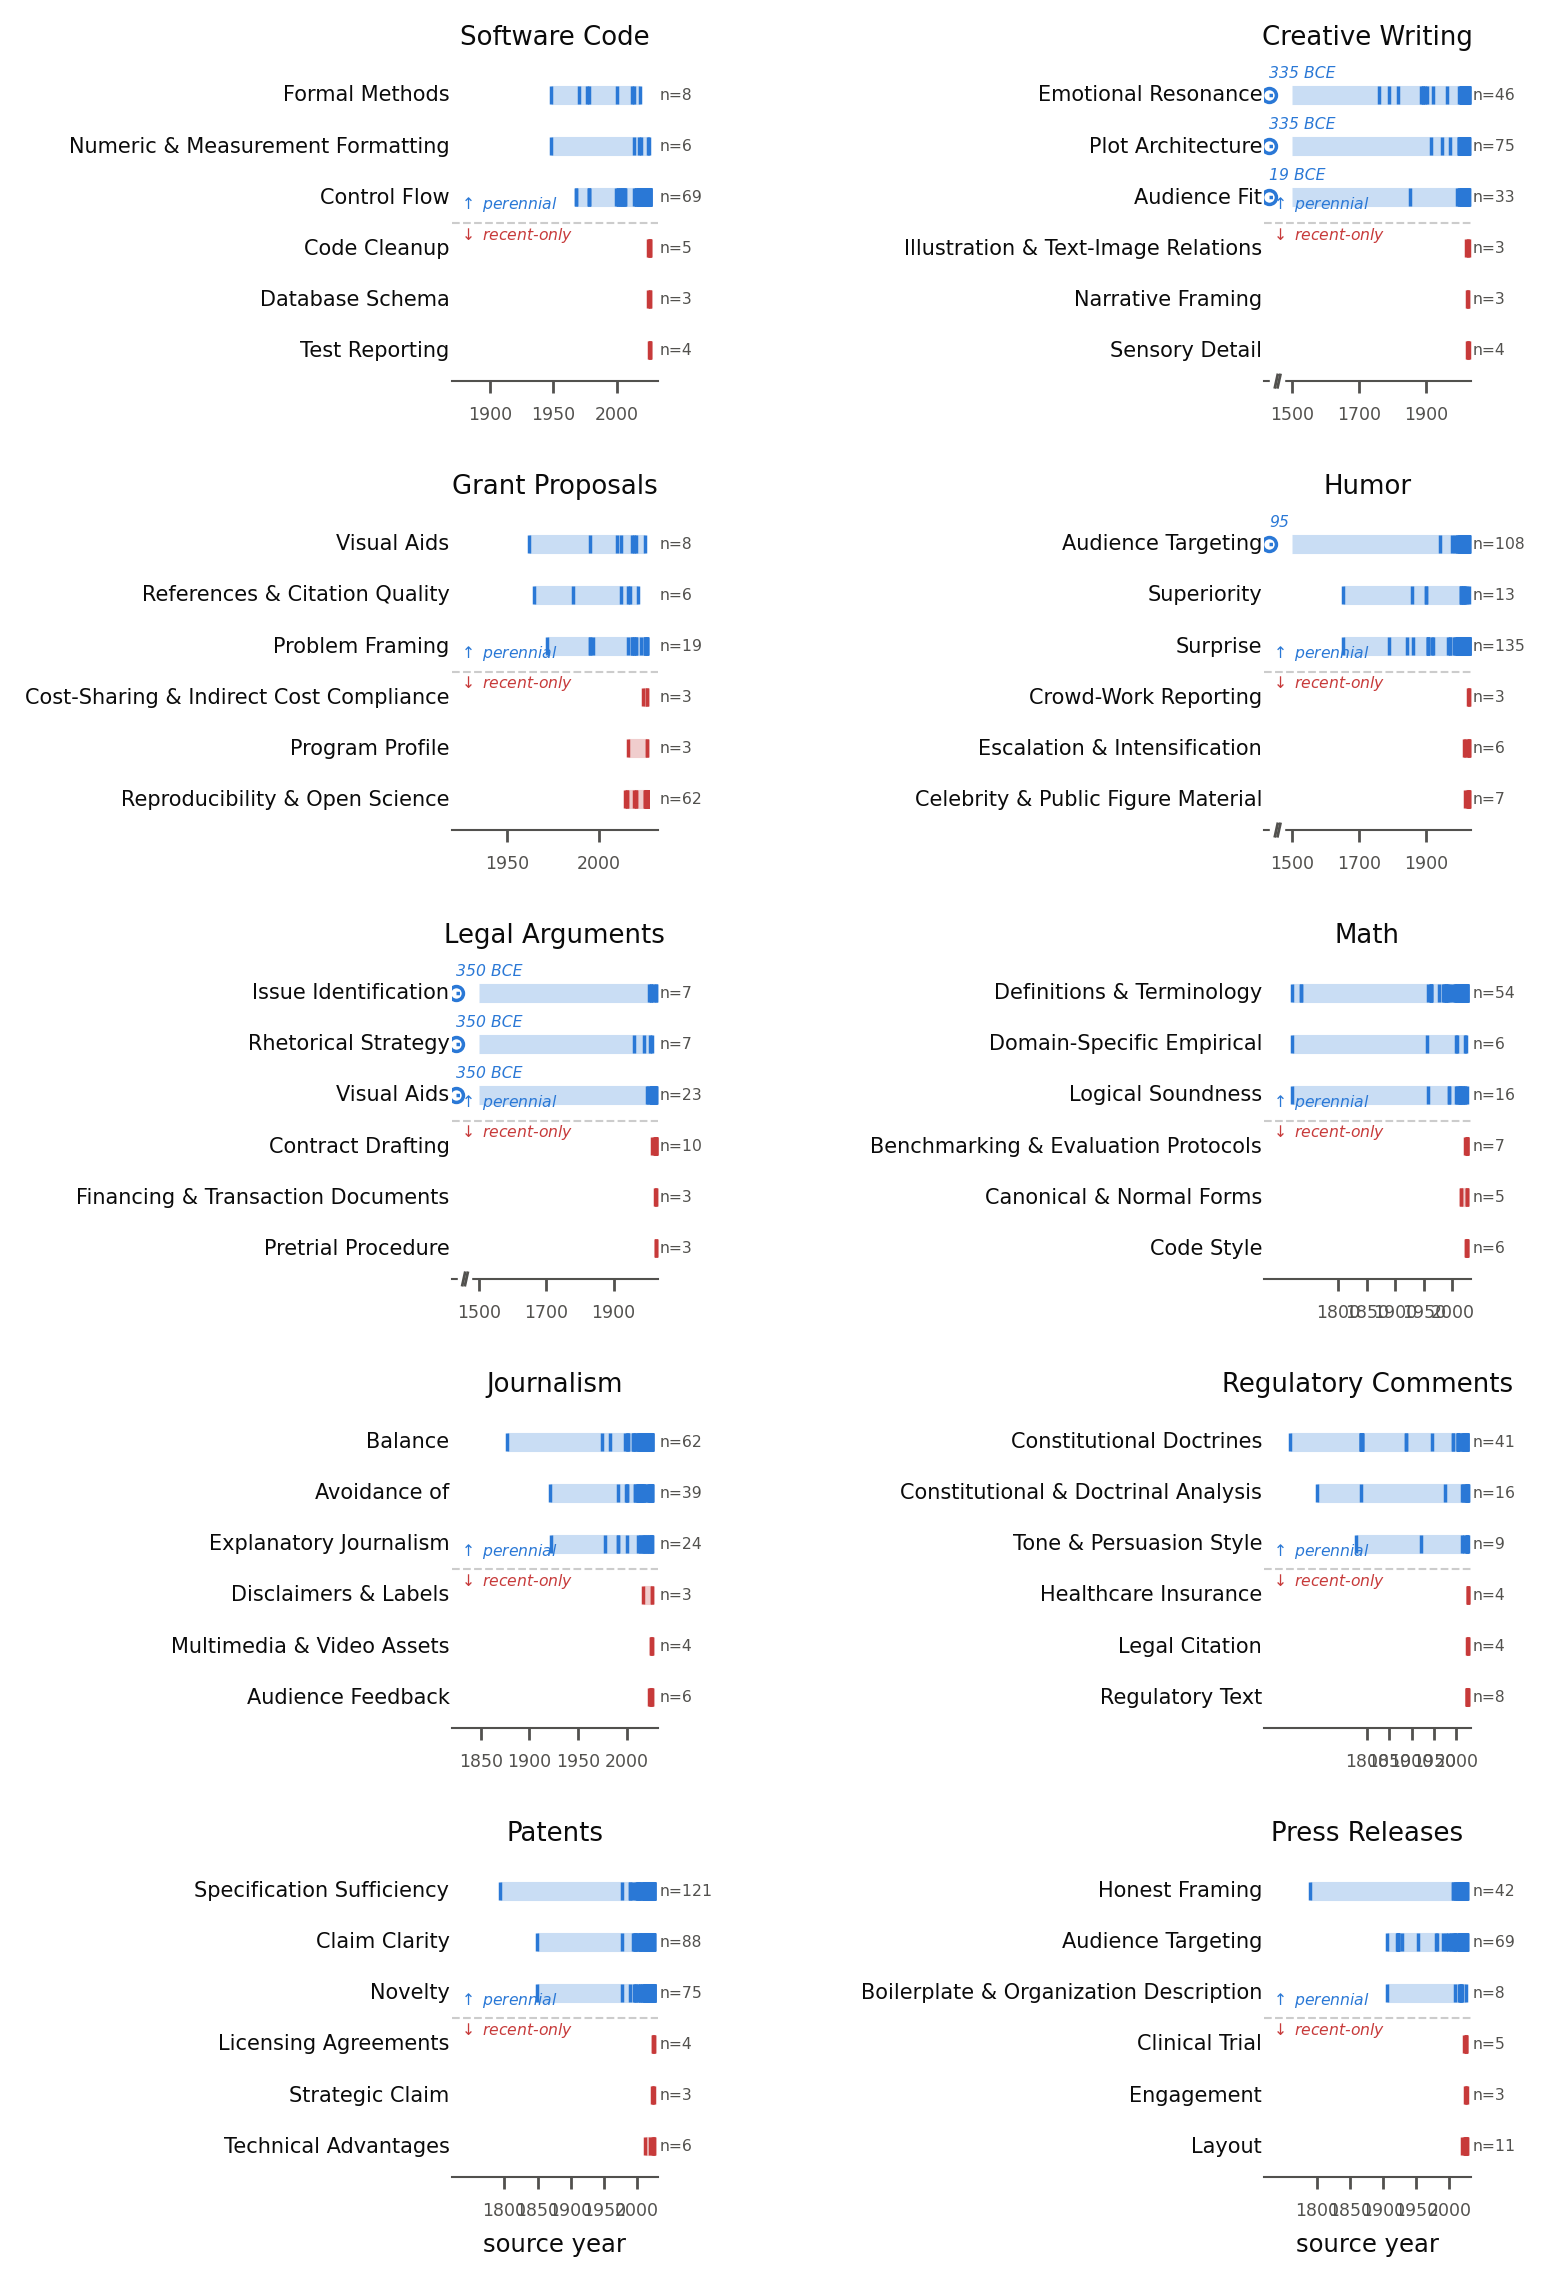

In [9]:

tasks=[t for t in sorted(mentions.task.unique()) if t!='peer-review']
fig,axes=plt.subplots(5,2,figsize=(6.3,9.2),dpi=250)
for ax,t in zip(axes.flat,tasks):
    norm_age_panel(ax,t,label_fs=6)
for ax in axes.flat[len(tasks):]: ax.axis('off')
for ax in axes[-1]: ax.set_xlabel('source year',fontsize=7)
plt.tight_layout(w_pad=4.5,h_pad=1.6)
plt.savefig(f'{FIGS}/fig_norm_age_appendix.png',bbox_inches='tight'); plt.show()


## Saturation across strata (appendix): accumulation curves + missing-mass table

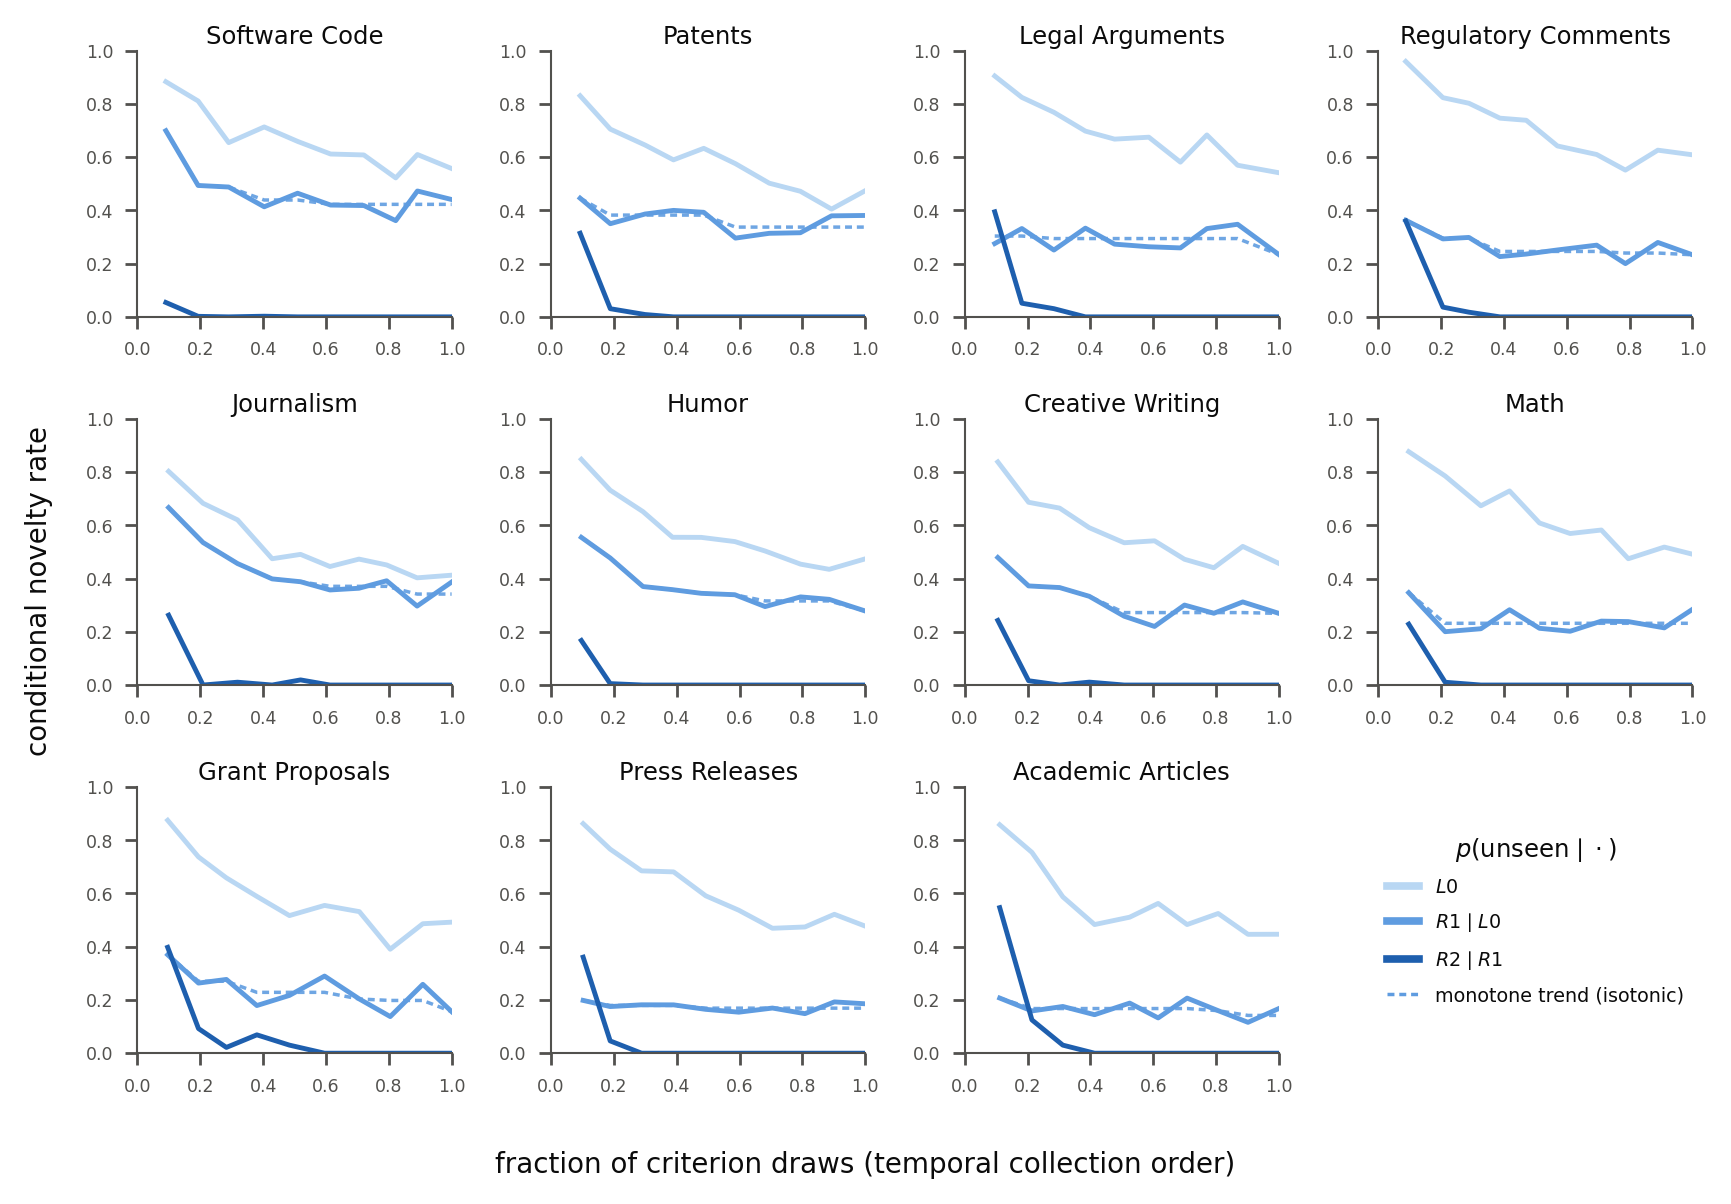

,L0,R1,R2,R3
Software Code,0.521,0.206,0.0,0.0
Creative Writing,0.424,0.114,0.0,0.0
Grant Proposals,0.459,0.105,0.0,0.0
Humor,0.426,0.124,0.0,0.0
Legal Arguments,0.558,0.159,0.0,0.0
Math,0.487,0.114,0.0,0.0
Journalism,0.395,0.131,0.0,0.0
Regulatory Comments,0.590,0.154,0.0,0.0
Patents,0.443,0.160,0.0,0.0
Academic Articles,0.432,0.069,0.0,0.0


In [10]:
# Figure 10 — CRF conditional novelty rates up the ladder (derivative view of accumulation).
# Legend now lives in the empty 12th panel (no longer overlapping Press Releases); labels are
# self-explanatory; panels ordered by R1 openness (GT missing mass, desc) so the construct-rate
# gradient reads left->right. Thin dashed guide = isotonic (monotone-decreasing) fit to the
# construct rate: the empirical windowed rate is jagged noise around a slowly declining trend.
from sklearn.isotonic import IsotonicRegression
import matplotlib.lines as mlines
rich=json.load(open(f'{ROOT}/outputs/lexicon/richness_20260720.json'))
LEV=[('$L0$','#b9d7f3'),
     ('$R1 \\mid L0$','#5f9ce0'),
     ('$R2 \\mid R1$','#1e5fae')]
def windowed_ratio(num,den,xnorm,nseg=10):
    idx=np.linspace(0,len(num)-1,nseg+1).astype(int)
    xs=[]; ys=[]
    for a,b in zip(idx[:-1],idx[1:]):
        dd=den[b]-den[a]
        if dd<=0: continue
        xs.append(xnorm[b]); ys.append((num[b]-num[a])/dd)
    return np.array(xs),np.array(ys)
tasks=sorted(rich,key=lambda t:-rich[t]['grains']['R1']['gt_missing_mass'])
fig,axes=plt.subplots(3,4,figsize=(7.0,4.8),dpi=250)
for ax,t in zip(axes.flat,tasks):
    g=rich[t]['grains']
    L0=np.array(g['L0']['accumulation_curve'],dtype=float)
    R1=np.array(g['R1']['accumulation_curve'],dtype=float)
    R2=np.array(g['R2']['accumulation_curve'],dtype=float) if 'R2' in g else None
    xnorm=L0[:,0]/L0[-1,0]
    for i,((lab,col),num,den) in enumerate((( LEV[0],L0[:,1],L0[:,0]),(LEV[1],R1[:,1],L0[:,1]),
                              (LEV[2],(R2[:,1] if R2 is not None else None),R1[:,1]))):
        if num is None: continue
        xs,ys=windowed_ratio(num,den,xnorm)
        ax.plot(xs,ys,color=col,lw=1.4)
        if i==1 and len(xs)>=3:   # monotone-decreasing guide on the construct rate
            iso=IsotonicRegression(increasing=False).fit_transform(xs,ys)
            ax.plot(xs,iso,color=col,lw=1.0,ls=(0,(2,1.4)),alpha=.9)
    ax.set_title(GEN[t],fontsize=7,pad=2)
    ax.set_ylim(0,1.0); ax.set_xlim(0,1)
    ax.tick_params(labelsize=5); ax.spines[['top','right']].set_visible(False)
# empty 12th panel -> legend + reading note
lp=axes.flat[len(tasks)]; lp.axis('off')
handles=[mlines.Line2D([],[],color=c,lw=2.2,label=l) for l,c in LEV]
handles.append(mlines.Line2D([],[],color='#5f9ce0',lw=1.0,ls=(0,(2,1.4)),label='monotone trend (isotonic)'))
lp.legend(handles=handles,frameon=False,fontsize=5.5,loc='center',
          title='$p(\\mathrm{unseen} \\mid \\cdot)$',title_fontsize=7,handlelength=1.7,labelspacing=.75)
for ax in axes.flat[len(tasks)+1:]: ax.axis('off')
fig.supxlabel('fraction of criterion draws (temporal collection order)',fontsize=8)
fig.supylabel('conditional novelty rate',fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIGS}/fig_saturation_appendix.png',bbox_inches='tight'); plt.show()
rows={}
for t in sorted(rich):
    rows[GEN[t]]={lv:rich[t]['grains'][lv]['gt_missing_mass'] for lv in ('L0','R1','R2','R3') if lv in rich[t]['grains']}
sat=pd.DataFrame(rows).T.round(3)
sat

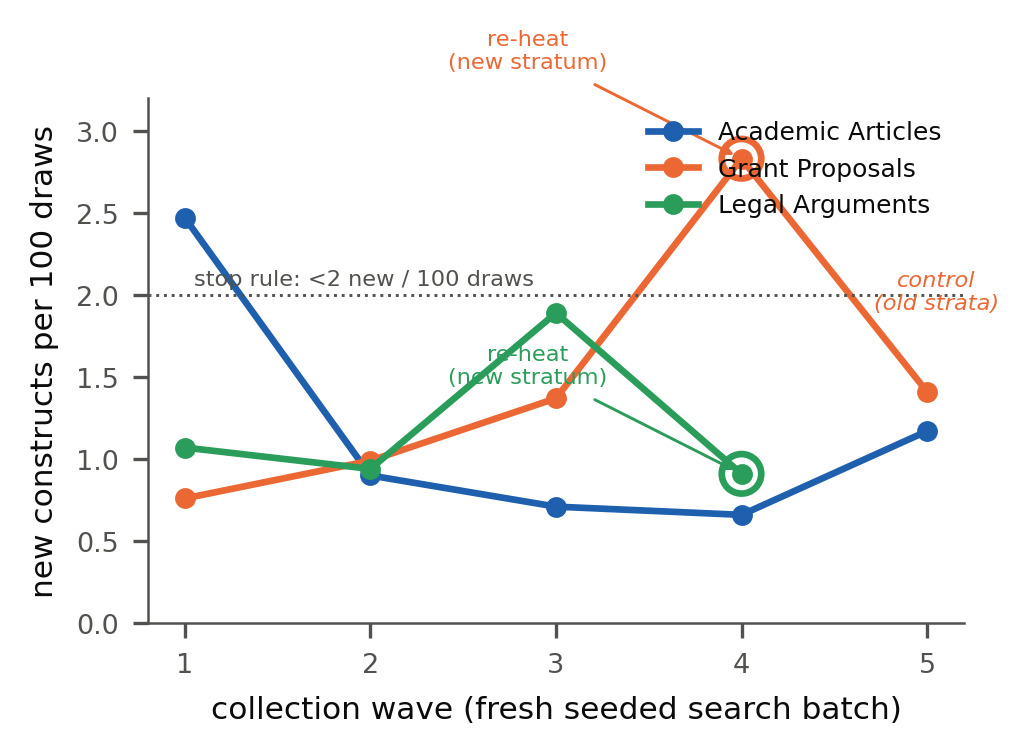

grant reheat jump: 2.83 vs control 1.41 | legal reheat: 0.91 (no jump)


In [11]:
# Figure — re-heating probe: recent W15 saturation campaigns (Academic Articles / Grants / Legal).
# Each wave = one seeded search batch; y = new constructs (R1) per 100 draws after adversarially
# hardened seating. A wave is a *re-heating probe* when it injects a fresh sub-population stratum
# (funder class / venue class); we ask whether novelty jumps. It does for grants (mission-specific
# criteria re-open the frontier) but NOT for legal (a shared argument-quality core), while academic
# review plateaus in place. The plateau is a STEADY-STATE discovery rate, not exhaustion.
CAMP={
 'Academic Articles':{'c':'#1e5fae','w':[(1,2.47,None),(2,0.90,None),(3,0.71,None),(4,0.66,None),(5,1.17,None)]},
 'Grant Proposals':  {'c':'#eb6834','w':[(1,0.76,None),(2,0.99,None),(3,1.37,None),(4,2.83,'reheat'),(5,1.41,'control')]},
 'Legal Arguments':  {'c':'#2a9d5a','w':[(1,1.07,None),(2,0.94,None),(3,1.89,None),(4,0.91,'reheat')]},
}
fig,ax=plt.subplots(figsize=(3.5,2.6),dpi=300)
for nm,d in CAMP.items():
    xs=[w[0] for w in d['w']]; ys=[w[1] for w in d['w']]
    ax.plot(xs,ys,color=d['c'],lw=1.6,marker='o',ms=4,label=nm,zorder=2)
    for wv,rate,tag in d['w']:
        if tag=='reheat':
            ax.scatter([wv],[rate],s=90,facecolor='none',edgecolor=d['c'],lw=1.6,zorder=3)
            ax.annotate('re-heat\n(new stratum)',xy=(wv,rate),xytext=(wv-1.15,rate+.55),
                        fontsize=5.4,color=d['c'],ha='center',
                        arrowprops=dict(arrowstyle='->',color=d['c'],lw=.7))
        if tag=='control':
            ax.annotate('control\n(old strata)',xy=(wv,rate),xytext=(wv+.05,rate+.5),
                        fontsize=5.4,color=d['c'],ha='center',style='italic')
ax.axhline(2.0,color=MUTED,lw=.7,ls=':')
ax.text(1.05,2.06,'stop rule: <2 new / 100 draws',fontsize=5.4,color=MUTED)
ax.set_xlabel('collection wave (fresh seeded search batch)',fontsize=7.5)
ax.set_ylabel('new constructs per 100 draws',fontsize=7.5)
ax.set_xticks([1,2,3,4,5]); ax.set_ylim(0,3.2); ax.tick_params(labelsize=6.5)
ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False,fontsize=6,loc='upper right')
plt.tight_layout(); plt.savefig(f'{FIGS}/fig_reheat_probe.png',bbox_inches='tight'); plt.show()
print('grant reheat jump:',2.83,'vs control',1.41,'| legal reheat:',0.91,'(no jump)')

## Main-body scatter: formal-form AUC vs informal-form AUC per metric (replaces Table 2 in body)

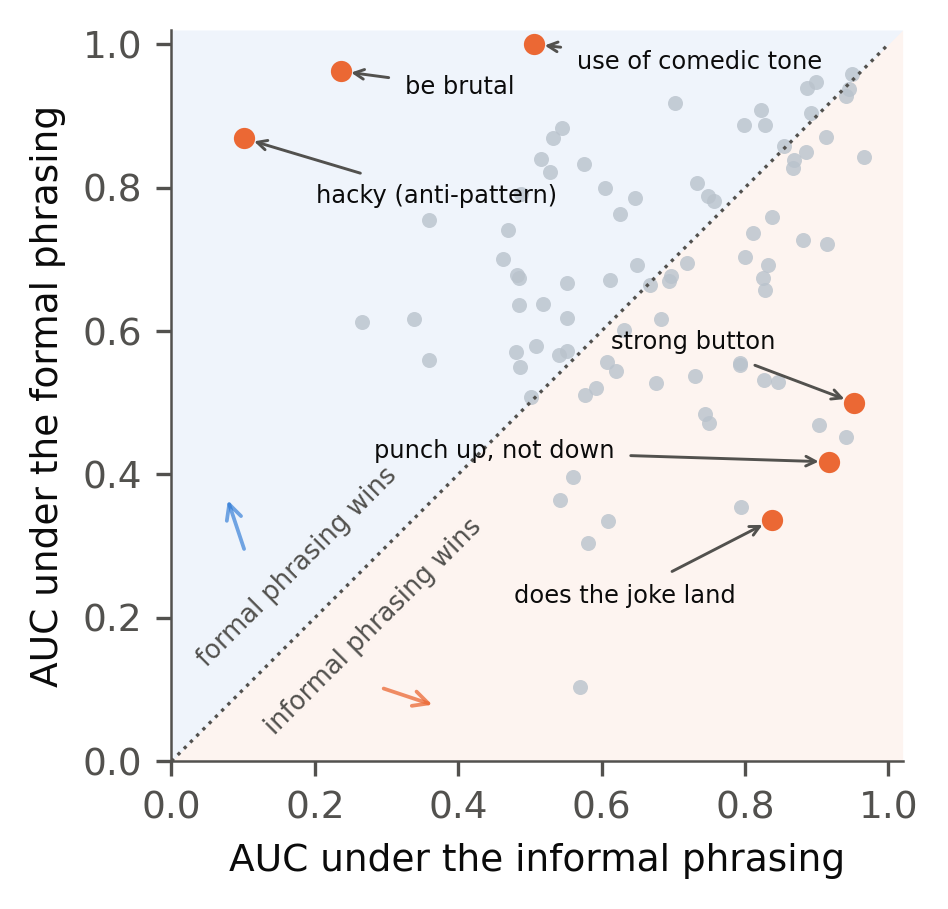

In [12]:

# Fig 9 — form-effect scatter. Region labels CORRECTED and set along the diagonal near its
# top end (formal wins = above the diagonal, informal wins = below). No crossing arrows.
p15=json.load(open(f'{ROOT}/outputs/lexicon/prereg15_results_20260723.json'))['per_metric']
LBL={'a64':('hacky (anti-pattern)',(.10,-.09),'left'),
     'a118':('be brutal',(.09,-.032),'left'),
     'a2':('use of comedic tone',(.06,-.035),'left'),
     'a196':('strong button',(-.11,.075),'right'),
     'a0':('punch up, not down',(-.30,.005),'right'),
     'a32':('does the joke land',(-.05,-.115),'right')}
fig,ax=plt.subplots(figsize=(3.3,3.1),dpi=300)
ax.fill_between([0,1.02],[0,1.02],1.02,color=BLUE,alpha=.075,linewidth=0,zorder=0)
ax.fill_between([0,1.02],0,[0,1.02],color=ORANGE,alpha=.07,linewidth=0,zorder=0)
ax.plot([0,1],[0,1],color=MUTED,lw=.8,ls=':')
xs=[r['auc_low'] for r in p15]; ys=[r['auc_high'] for r in p15]
ax.scatter(xs,ys,c='#b9c2cc',s=13,alpha=.8,linewidths=0)
for r in p15:
    if r['mid'] in LBL:
        nm,off,ha=LBL[r['mid']]
        ax.scatter([r['auc_low']],[r['auc_high']],c=ORANGE,s=26,zorder=3,linewidths=0)
        ax.annotate(nm,xy=(r['auc_low'],r['auc_high']),
                    xytext=(r['auc_low']+off[0],r['auc_high']+off[1]),
                    fontsize=5.8,color=INK,ha=ha,
                    arrowprops=dict(arrowstyle='->',color=MUTED,lw=.7,shrinkB=2.5))
ax.set_xlabel('AUC under the informal phrasing')
ax.set_ylabel('AUC under the formal phrasing')
ax.set_xlim(0,1.02); ax.set_ylim(0,1.02); ax.set_aspect('equal')
ax.spines[['top','right']].set_visible(False)
# region labels riding the diagonal, near its top end
ax.text(.055,.125,'formal phrasing wins',fontsize=6.2,color=MUTED,rotation=45,
        rotation_mode='anchor',ha='left',va='bottom')
ax.text(.125,.055,'informal phrasing wins',fontsize=6.2,color=MUTED,rotation=45,
        rotation_mode='anchor',ha='left',va='top')
d=.06  # perpendicular arrows beside the region labels, clear of the text
ax.annotate('',xy=(.075-0,.315+d),xytext=(.105,.285),
            arrowprops=dict(arrowstyle='->',color=BLUE,lw=.9,alpha=.65))
ax.annotate('',xy=(.315+d,.075),xytext=(.285,.105),
            arrowprops=dict(arrowstyle='->',color=ORANGE,lw=.9,alpha=.75))
plt.tight_layout(); plt.savefig(f'{FIGS}/fig_form_scatter.png',bbox_inches='tight'); plt.show()


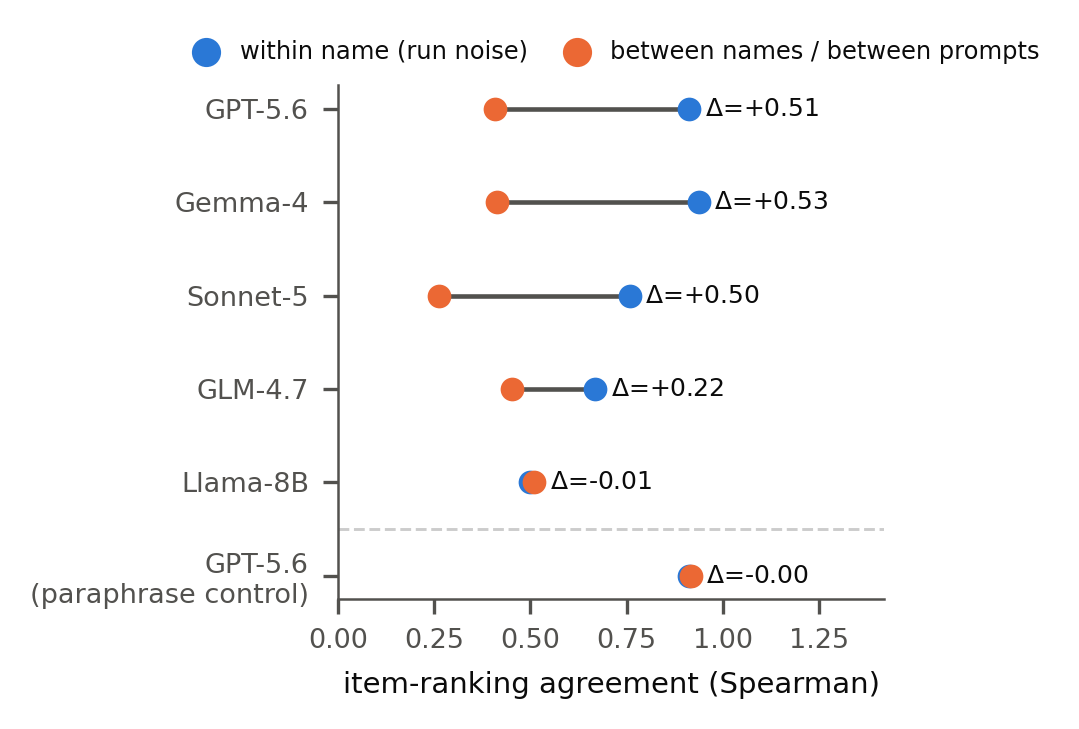

In [13]:

# dumbbells with the paraphrase control as a sixth row (same encoding, zero gap)
fam=D['fig3a_families']
names=['GPT-5.6','Gemma-4','Claude','GLM-4.7','Llama-8B']
DISP={'Claude':'Sonnet-5'}
fig,a=plt.subplots(figsize=(3.3,2.5),dpi=300)
rows=[(DISP.get(n,n),fam[n]['within'],fam[n]['within']-fam[n]['delta'],fam[n]['delta']) for n in names]
nb_=D['fig3b_name_vs_scaffold']
w_gpt=fam['GPT-5.6']['within']
rows.append(('GPT-5.6\n(paraphrase control)',w_gpt,w_gpt-nb_['D_scaffold'],nb_['D_scaffold']))
y=np.arange(len(rows))
for yi,(n,w,btw,d) in zip(y,rows):
    a.plot([btw,w],[yi,yi],color=MUTED,lw=1.1,zorder=1)
    a.scatter([w],[yi],color=BLUE,s=22,zorder=2)
    a.scatter([btw],[yi],color=ORANGE,s=22,zorder=3)
    a.text(max(w,btw)+.04,yi,f"$\\Delta$={d:+.2f}",va='center',fontsize=6,color=INK)
a.axhline(len(names)-.5,color='#cccccc',lw=.7,ls='--')
a.set_yticks(y,[r[0] for r in rows],fontsize=6.3); a.invert_yaxis(); a.set_xlim(0,1.42)
a.tick_params(labelsize=6.5)
a.set_xlabel('item-ranking agreement (Spearman)',fontsize=7)
a.spines[['top','right']].set_visible(False)
a.scatter([],[],color=BLUE,label='within name (run noise)')
a.scatter([],[],color=ORANGE,label='between names / between prompts')
a.legend(frameon=False,fontsize=5.8,loc='lower center',bbox_to_anchor=(0.5,1.0),ncol=2,columnspacing=1.0,handletextpad=.4)
plt.tight_layout(); plt.savefig(f'{FIGS}/fig_name_dumbbell.png',bbox_inches='tight'); plt.show()


## Cover figure — norm specificity (census buckets; will be regenerated with the rescored lay+community metrics when the Codex lane lands)

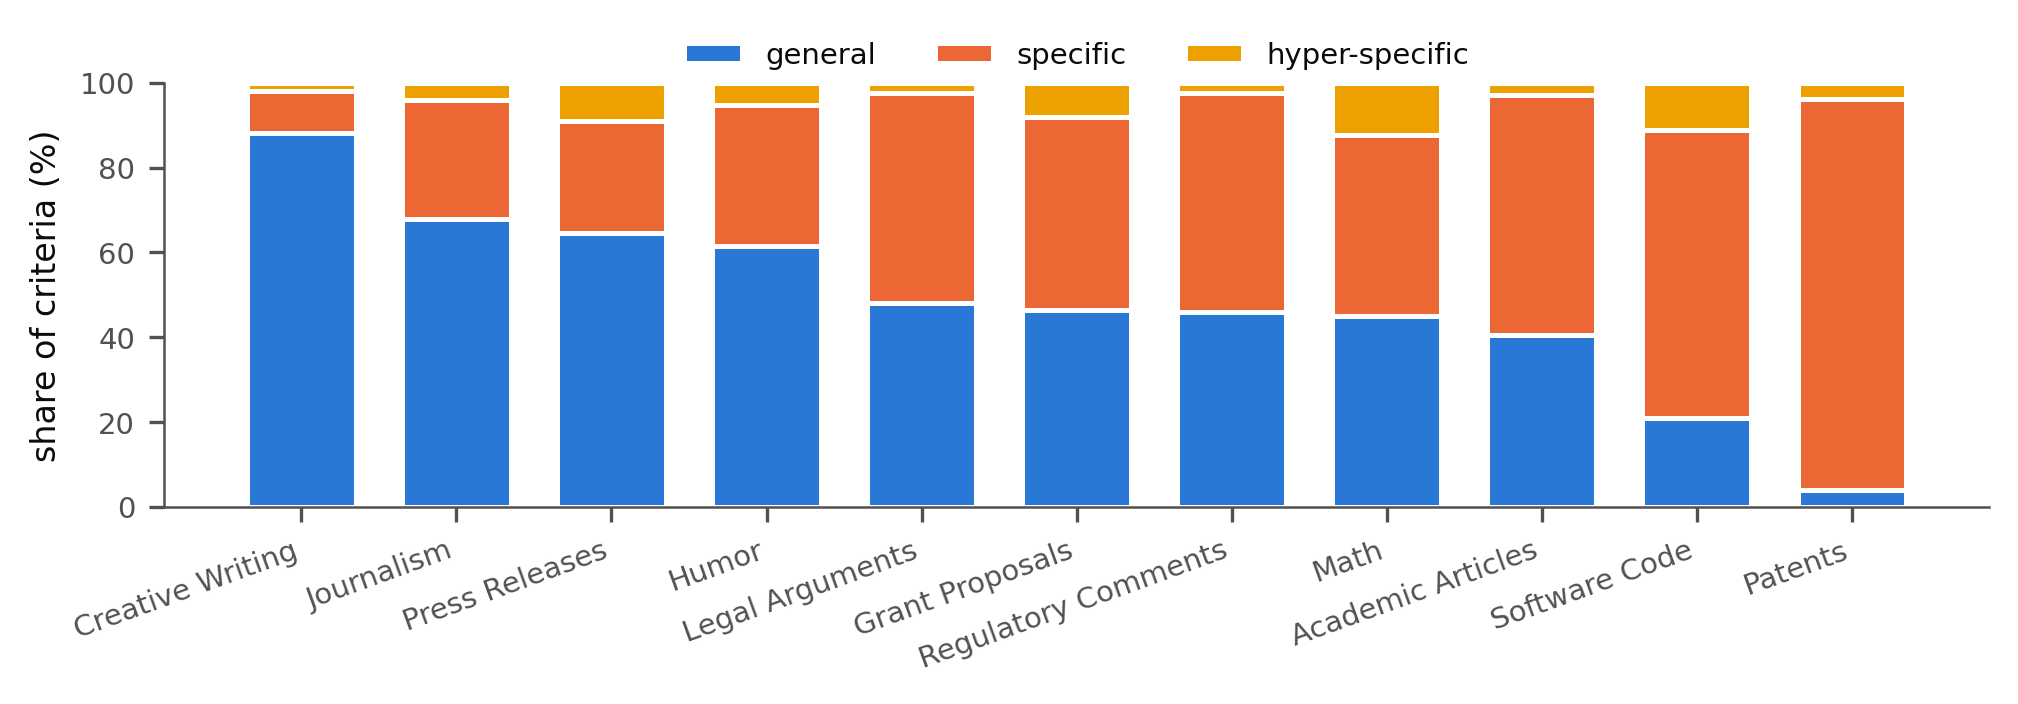

pool sizes: census 53413 new 7961


In [14]:

import collections
canon=[json.loads(l) for l in open(f'{ROOT}/outputs/analyses/canon_all_real_forms.jsonl')]
newm=[json.loads(l) for l in open(f'{ROOT}/outputs/lexicon/specificity_newmetrics_20260723.jsonl')]
DMAP={"humor_comedy":"humor","creative_writing":"creative-writing","news_journalism":"news-homepages",
 "math":"math-stackexchange","programming_code":"code-review","law_legal":"legal-outcome-prediction",
 "patents_inventing":"patents","grants_nonprofit":"grant-funding",
 "press_releases_pr_marketing":"press-releases","peer_review_academia":"peer-review",
 "public_comments_regulation":"notice-and-comment"}
YEL='#eda100'
BUCK=[('general',BLUE),('specific',ORANGE),('hyper_specific',YEL)]
cnt=collections.Counter()
for r in canon: cnt[(r['task'],r['bucket'])]+=1
for r in newm:
    t=DMAP.get(r['task'],r['task'])
    if t in GEN: cnt[(t,r['bucket'])]+=1
tasks=sorted({t for t,_ in cnt},key=lambda t:-cnt[(t,'general')]/max(1,sum(cnt[(t,b)] for b,_ in BUCK)))
fig,ax=plt.subplots(figsize=(6.8,2.5),dpi=300)
x=np.arange(len(tasks)); bot=np.zeros(len(tasks))
for b,col in BUCK:
    v=np.array([cnt[(t,b)]/sum(cnt[(t,bb)] for bb,_ in BUCK) for t in tasks])*100
    ax.bar(x,v,bottom=bot,color=col,width=.7,label=b.replace('_','-'),edgecolor='white',linewidth=1.2)
    bot+=v
ax.set_xticks(x,[GEN[t] for t in tasks],rotation=20,ha='right',fontsize=7.5)
ax.set_ylabel('share of criteria (%)',fontsize=8)
ax.set_ylim(0,100); ax.tick_params(labelsize=7)
ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False,fontsize=7,ncol=3,loc='upper center',bbox_to_anchor=(.5,1.16))
plt.tight_layout(); plt.savefig(f'{FIGS}/fig_specificity_cover.png',bbox_inches='tight'); plt.show()
print('pool sizes: census',len(canon),'new',len(newm))


## Fig 4 right panel — REAL naming distributions (10 fresh GPT-5.6 threads vs the 3 human namings of the recognition construct): 10/10 LLM samples said 'aha moment'.

findfont: Font family 'xkcd' not found.


findfont: Font family 'xkcd Script' not found.


findfont: Font family 'Comic Neue' not found.


findfont: Font family 'xkcd' not found.


findfont: Font family 'xkcd Script' not found.


...

findfont: Font family 'xkcd Script' not found.


findfont: Font family 'Comic Neue' not found.


findfont: Font family 'xkcd' not found.


findfont: Font family 'xkcd Script' not found.


findfont: Font family 'Comic Neue' not found.


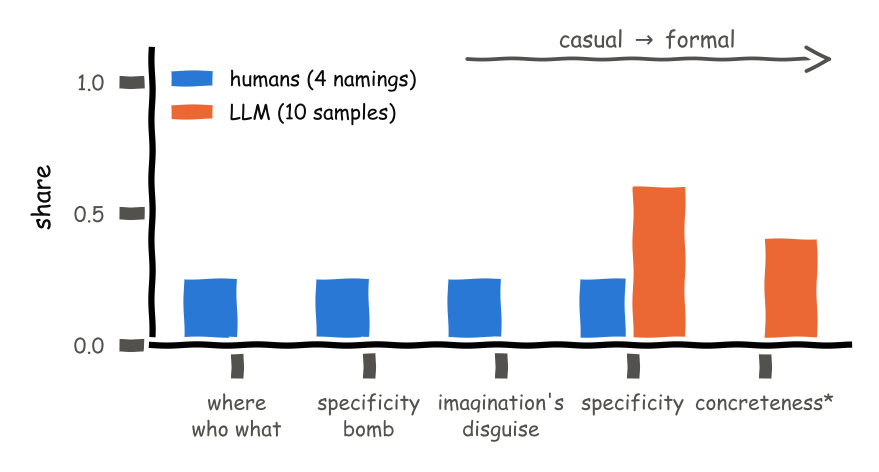

In [15]:

# REAL data: humor construct 2516 - 4 attested human namings (each n=1) ordered by judged
# formality; LLM = 10 fresh GPT-5.6 threads: 6x 'specificity', 4x 'concrete specificity'.
labels=['where\nwho what','specificity\nbomb','imagination\'s\ndisguise','specificity','concreteness*']
hum=np.array([1,1,1,1,0])/4
llm=np.array([0,0,0,6,4])/10
with plt.xkcd(scale=.6,length=60,randomness=1):
    fig,ax=plt.subplots(figsize=(3.15,1.8),dpi=300)
    x=np.arange(len(labels)); w=.4
    ax.bar(x-w/2,hum,width=w,color=BLUE,label='humans (4 namings)')
    ax.bar(x+w/2,llm,width=w,color=ORANGE,label='LLM (10 samples)')
    ax.set_xticks(x,labels,fontsize=4.9)
    ax.set_yticks([0,.5,1.0]); ax.set_ylim(0,1.12)
    ax.tick_params(labelsize=5)
    ax.set_ylabel('share',fontsize=6)
    ax.annotate('',xy=(0.99,0.97),xytext=(0.44,0.97),xycoords='axes fraction',
                arrowprops=dict(arrowstyle='->',color=MUTED,lw=.9))
    ax.text(0.71,1.01,'casual $\\rightarrow$ formal',transform=ax.transAxes,fontsize=5.5,color=MUTED,ha='center')
    ax.legend(frameon=False,fontsize=5,loc='upper left')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); plt.savefig(f'{FIGS}/fig4_name_dist.png',bbox_inches='tight'); plt.show()


## NEW main-body figure — the two-axis dissociation of speaker position
x = mean judged formality (register: institutional voice), y = metaphoricity rate (figuration: adjudication function). Big points = class means; small dots = per-domain values for community rules and lay critics (PREREG-10R/13 data).

cells plotted: {'community_rule': 46, 'individual_lay': 73}


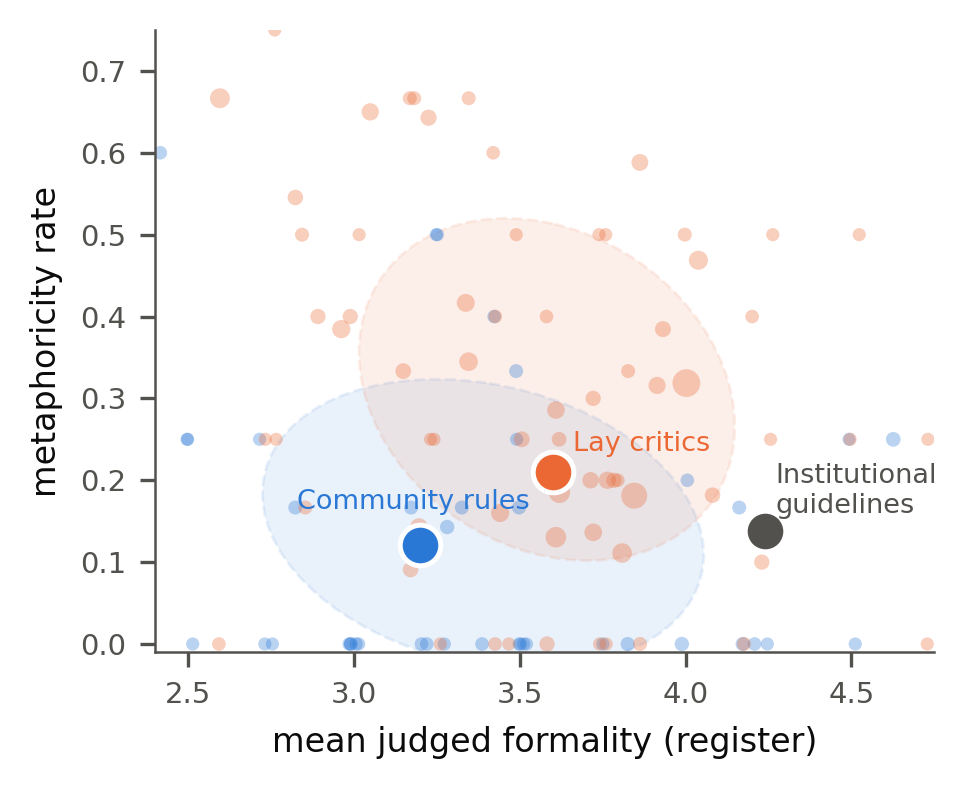

In [16]:

# Fig 8 (dissociation) — DENSIFIED: small dots are (task x class x sub-community) cells
# with term-level judgments joined across instruments: formality from PREREG-10R
# (p10_key map + p10_out), metaphoricity from PREREG-13 (axis_metaphoricity_prereg13).
# Lay cells = (task, subfield_short); community cells = (task, subreddit). Cells need
# >=4 terms with BOTH judgments. Big points = class means (canonical p13/table2 values).
import glob, ast, collections, re as _re
p13=json.load(open(f'{ROOT}/outputs/lexicon/prereg13_results_20260723.json'))
LEX=f'{ROOT}/outputs/lexicon'
def _norm(t): return _re.sub(r'[^a-z0-9 ]+',' ',(t or '').lower()).strip()
# term -> formality (mean across judged rows)
kmap=json.load(open(f'{LEX}/register_corpus_20260723/p10_key.json'))['map']
fsum=collections.defaultdict(list)
for fp in sorted(glob.glob(f'{LEX}/register_corpus_20260723/p10_out_*.jsonl')):
    for l in open(fp):
        r=json.loads(l)
        m=kmap.get(r['id'])
        if m and isinstance(r.get('formality'),(int,float)):
            fsum[(m['cls'],_norm(m['term']))].append(r['formality'])
form={k:np.mean(v) for k,v in fsum.items()}
# term -> metaphoricity score (0/1)
met={}
for l in open(f'{LEX}/axis_metaphoricity_prereg13_20260723.jsonl'):
    r=json.loads(l); met[(r['cls'],_norm(r['variant']))]=r['score']
# term -> (task, subcell)
cells=collections.defaultdict(list)   # (cls, task, sub) -> [(form, met)]
for fp in glob.glob(f'{LEX}/register_corpus_20260723/lay_extract_*.jsonl'):
    for l in open(fp):
        try: r=json.loads(l)
        except Exception: continue
        if r.get('doc_summary_row') or not r.get('head_term'): continue
        t=_norm(r['head_term']); k=('individual_lay',t)
        if k in met and k in form:
            cells[('individual_lay',r['task'],r.get('subfield_short') or '?')].append((form[k],met[k]))
DMAP={'creative_writing':'creative-writing','programming_code':'code-review','humor_comedy':'humor',
 'news_journalism':'news-homepages','math':'math-stackexchange','law_legal':'legal-outcome-prediction',
 'patents_inventing':'patents','grants_nonprofit':'grant-funding','press_releases_pr_marketing':'press-releases',
 'peer_review_academia':'peer-review','public_comments_regulation':'notice-and-comment'}
for l in open(f'{LEX}/community_rule_criteria_20260723.jsonl'):
    r=json.loads(l)
    uses=ast.literal_eval(r['uses']) if isinstance(r['uses'],str) else r['uses']
    terms=ast.literal_eval(r['criterion_terms']) if isinstance(r['criterion_terms'],str) else r['criterion_terms']
    for dom,sub,_n in uses:
        task=DMAP.get(dom,dom)
        for t in terms:
            k=('community_rule',_norm(t))
            if k in met and k in form:
                cells[('community_rule',task,sub)].append((form[k],met[k]))
MINN=4
pts={'community_rule':[],'individual_lay':[]}
for (cls,task,sub),v in cells.items():
    if len(v)>=MINN:
        pts[cls].append((np.mean([x[0] for x in v]),np.mean([x[1] for x in v]),len(v)))
print('cells plotted:',{k:len(v) for k,v in pts.items()})
CLASS={'community_rule':('Community rules',BLUE),'individual_lay':('Lay critics',ORANGE),
       'official':('Institutional\nguidelines','#52514e')}
means={'community_rule':(3.20,p13['rates']['community_rule']),
       'individual_lay':(3.60,p13['rates']['individual_lay']),
       'official':(4.24,p13['rates']['official'])}
fig,ax=plt.subplots(figsize=(3.3,2.7),dpi=300)
rng=np.random.default_rng(0)
from matplotlib.patches import Ellipse
def cov_ellipse(ax,xs,ys,col,nsd=1.0):
    cov=np.cov(xs,ys); mx,my=xs.mean(),ys.mean()
    ev,evec=np.linalg.eigh(cov)
    ang=np.degrees(np.arctan2(evec[1,1],evec[0,1]))
    w,h=2*nsd*np.sqrt(ev[1]),2*nsd*np.sqrt(ev[0])
    ax.add_patch(Ellipse((mx,my),w,h,angle=ang,facecolor=col,alpha=.10,edgecolor=col,lw=.7,ls='--',zorder=0))
for cls,(nm,col) in [('community_rule',CLASS['community_rule']),('individual_lay',CLASS['individual_lay'])]:
    if not pts[cls]: continue
    xs=np.array([p[0] for p in pts[cls]])+rng.normal(0,.015,len(pts[cls]))
    ys=np.array([p[1] for p in pts[cls]])
    ns=np.array([p[2] for p in pts[cls]])
    cov_ellipse(ax,xs,ys,col)   # 1-sd region of the class's sub-community cells
    ax.scatter(xs,ys,s=4+3*np.sqrt(ns),color=col,alpha=.32,linewidths=0)
for k,(x,y) in means.items():
    nm,col=CLASS[k]
    ax.scatter([x],[y],color=col,s=95,zorder=3,edgecolor='white',linewidth=1.2)
    off={'community_rule':(-.02,.045),'individual_lay':(.06,.025),'official':(.03,.022)}[k]
    ax.text(x+off[0],y+off[1],nm,fontsize=6.5,color=col,ha='center' if k=='community_rule' else 'left')
ax.set_xlabel('mean judged formality (register)',fontsize=8)
ax.set_ylabel('metaphoricity rate',fontsize=8)
ax.set_xlim(2.4,4.75); ax.set_ylim(-.01,.75)
ax.tick_params(labelsize=7)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{FIGS}/fig_dissociation.png',bbox_inches='tight'); plt.show()


## Trial (appendix?) — closure funnel: lay criteria through the hierarchy

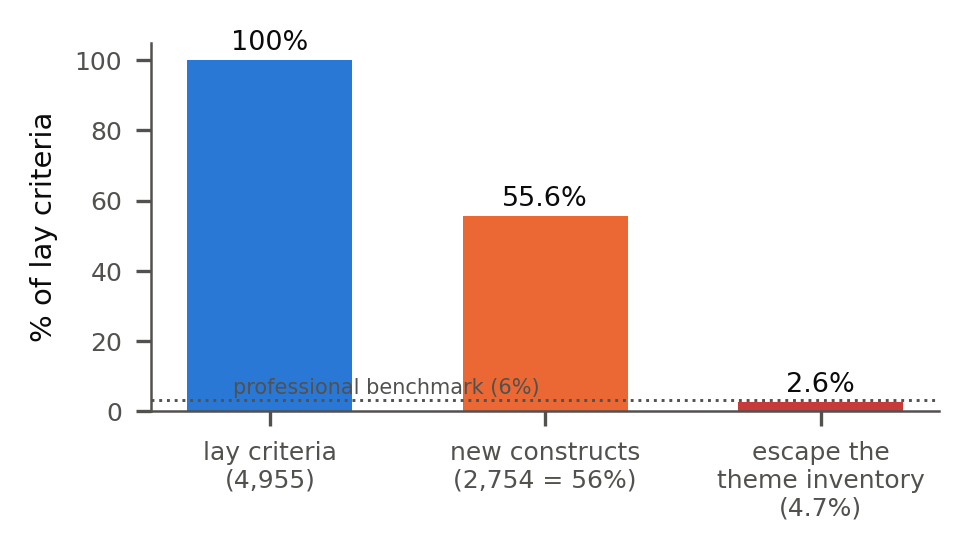

In [17]:

fig,ax=plt.subplots(figsize=(3.3,1.9),dpi=300)
stages=['lay criteria\n(4,955)','new constructs\n(2,754 = 56%)','escape the\ntheme inventory\n(4.7%)']
vals=[100,55.6,55.6*0.047]
ax.bar(range(3),vals,color=[BLUE,ORANGE,'#c73a3a'],width=.6)
for i,v in enumerate(vals):
    ax.text(i,v+3,f'{v:.1f}%' if i else '100%',ha='center',fontsize=6.5)
ax.axhline(55.6*0.06,color=MUTED,lw=.7,ls=':')
ax.text(0.98,55.6*0.06+1.8,'professional benchmark (6%)',fontsize=5,color=MUTED,ha='right')
ax.set_xticks(range(3),stages,fontsize=6)
ax.set_ylabel('% of lay criteria',fontsize=7)
ax.tick_params(labelsize=6)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{FIGS}/fig_closure_funnel.png',bbox_inches='tight'); plt.show()


## Fig — frame-calibration validation (PREREG-20): deception gap / list diversity / bound fan
Data: `outputs/lexicon/frame_calibration_20260724/{results,addendum_list_diversity}.json`

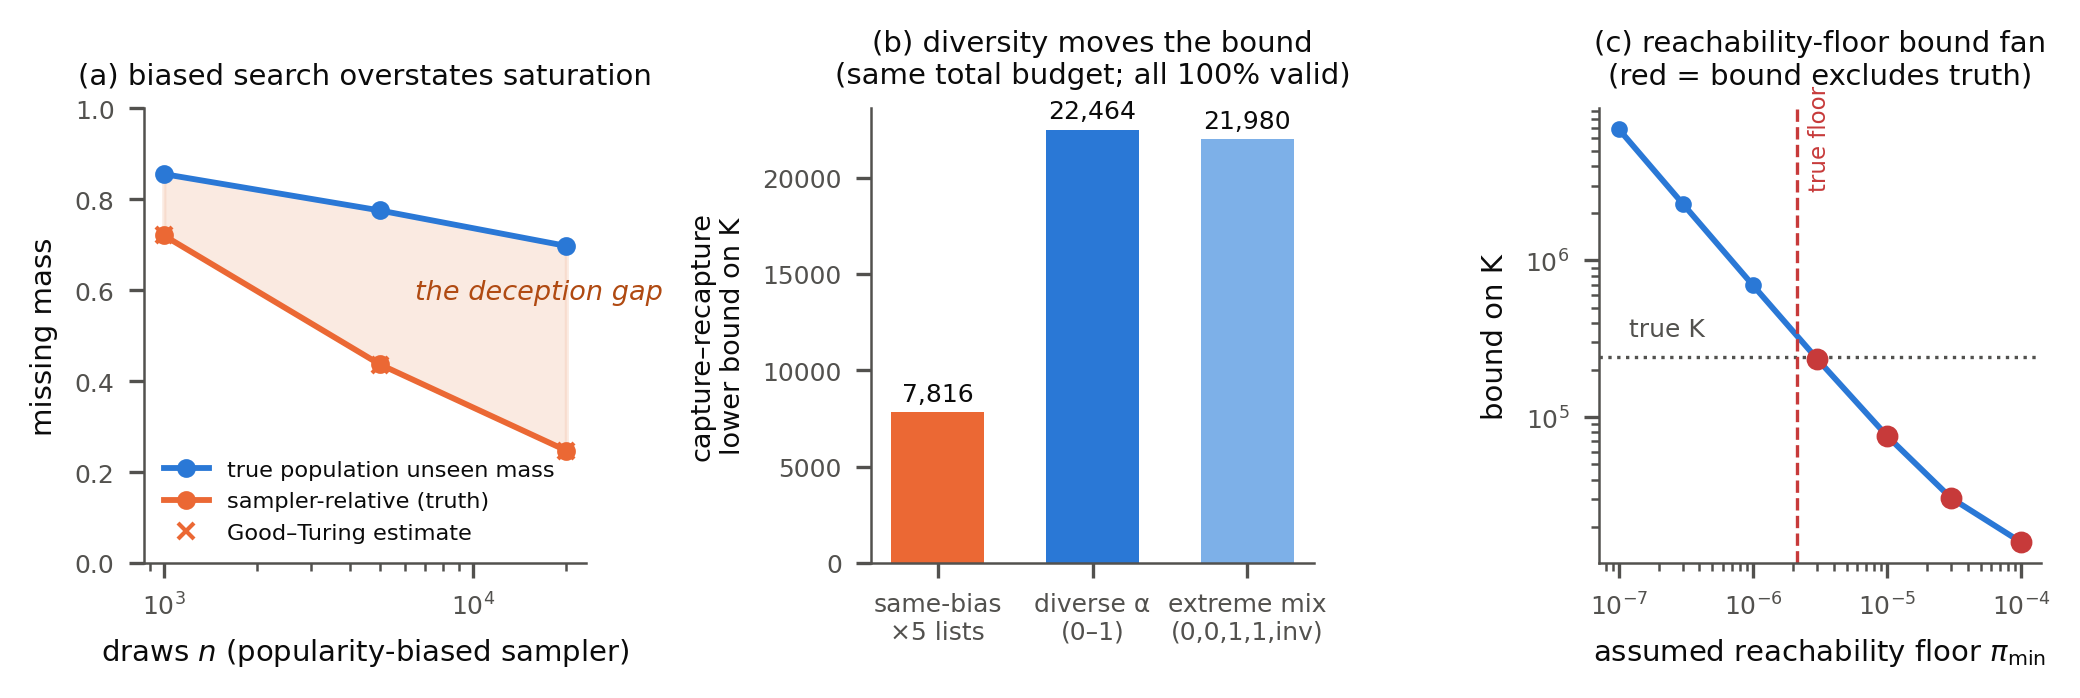

In [18]:
r=json.load(open(f'{ROOT}/outputs/lexicon/frame_calibration_20260724/results.json'))
add=json.load(open(f'{ROOT}/outputs/lexicon/frame_calibration_20260724/addendum_list_diversity.json'))
fig,(a,b,c)=plt.subplots(1,3,figsize=(7.0,2.4),dpi=300)
ns=[1000,5000,20000]
mu=[r['partA'][str(n)]['popularity_M_unif']['mean'] for n in ns]
ms=[r['partA'][str(n)]['popularity_M_samp']['mean'] for n in ns]
gt=[r['partA'][str(n)]['popularity_GT']['mean'] for n in ns]
a.plot(ns,mu,color=BLUE,marker='o',ms=3.5,lw=1.4,label='true population unseen mass')
a.plot(ns,ms,color=ORANGE,marker='o',ms=3.5,lw=1.4,label='sampler-relative (truth)')
a.plot(ns,gt,color=ORANGE,marker='x',ms=4,lw=0,label='Good\u2013Turing estimate')
a.fill_between(ns,ms,mu,color='#f3c4ab',alpha=.35)
a.text(6500,.58,'the deception gap',fontsize=6.5,color='#b04a12',style='italic')
a.set_xscale('log'); a.set_xlabel('draws $n$ (popularity-biased sampler)',fontsize=7)
a.set_ylabel('missing mass',fontsize=7); a.set_ylim(0,1)
a.legend(frameon=False,fontsize=5.4,loc='lower left')
a.set_title('(a) biased search overstates saturation',fontsize=7)
names=['same-bias\n\u00d75 lists','diverse \u03b1\n(0\u20131)','extreme mix\n(0,0,1,1,inv)']
vals=[add['same_bias(a=1)x5']['ml_chao_mean'],add['diverse(a=0,.25,.5,.75,1)']['ml_chao_mean'],add['extreme(a=0,0,1,1,inv)']['ml_chao_mean']]
b.bar(range(3),vals,color=[ORANGE,BLUE,'#7db0e8'],width=.6)
for i,v in enumerate(vals): b.text(i,v+600,f'{v:,.0f}',ha='center',fontsize=6)
b.set_xticks(range(3),names,fontsize=6)
b.set_ylabel('capture\u2013recapture\nlower bound on K',fontsize=6.5)
b.set_title('(b) diversity moves the bound\n(same total budget; all 100% valid)',fontsize=7)
fan=r['partC']['uniform']['fan']
x=[f['pi_min'] for f in fan]; y=[f['K_upper_bound'] for f in fan]; ok=[f['contains_truth'] for f in fan]
c.plot(x,y,color=BLUE,lw=1.4,marker='o',ms=3)
for xi,yi,o in zip(x,y,ok):
    if not o: c.scatter([xi],[yi],color='#c73a3a',s=18,zorder=3)
c.axhline(r['partC']['uniform']['true_K'],color=MUTED,lw=.8,ls=':')
c.text(1.2e-7,r['partC']['uniform']['true_K']*1.35,'true K',fontsize=6,color=MUTED)
c.axvline(r['partC']['uniform']['true_min_pi'],color='#c73a3a',lw=.8,ls='--')
c.text(r['partC']['uniform']['true_min_pi']*1.2,3e6,'true floor',fontsize=5.5,color='#c73a3a',rotation=90)
c.set_xscale('log'); c.set_yscale('log')
c.set_xlabel('assumed reachability floor $\\pi_{\\min}$',fontsize=7)
c.set_ylabel('bound on K',fontsize=7)
c.set_title('(c) reachability-floor bound fan\n(red = bound excludes truth)',fontsize=7)
for ax in (a,b,c): ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=6)
plt.tight_layout(); plt.savefig(f'{FIGS}/fig_frame_calibration.png',bbox_inches='tight'); plt.show()

## Fig — source provenance heatmap (where the criteria come from)
Data: `notebooks/_explore_cache/pages.parquet` (orientation × task).

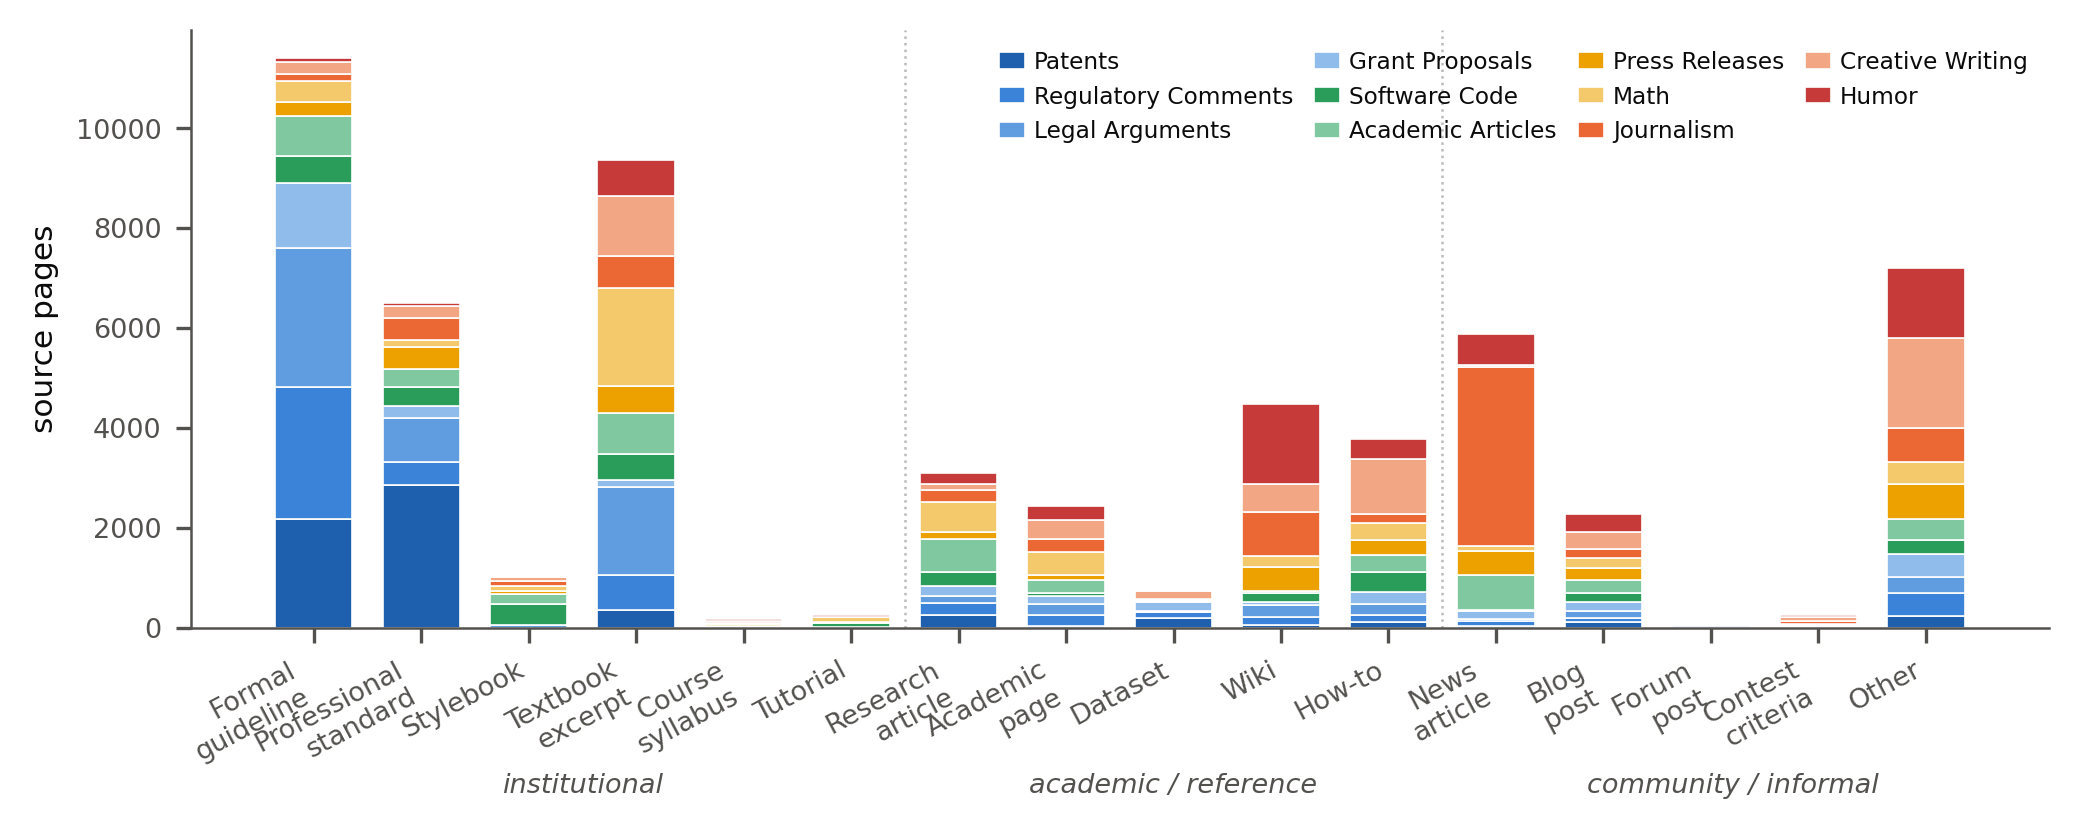

In [19]:
df=pd.read_parquet(f'{ROOT}/notebooks/_explore_cache/pages.parquet')
ct=pd.crosstab(df.task,df.orientation).drop(columns=['error'])
ORD=['formal_guideline','professional_standard','stylebook','textbook_excerpt','course_syllabus','tutorial',
     'research_article','academic_page','dataset','wiki','how_to','news_article','blog_post','forum_post',
     'contest_criteria','other']
ct=ct[ORD]
LBL={'formal_guideline':'Formal\nguideline','professional_standard':'Professional\nstandard','stylebook':'Stylebook',
 'textbook_excerpt':'Textbook\nexcerpt','course_syllabus':'Course\nsyllabus','tutorial':'Tutorial',
 'research_article':'Research\narticle','academic_page':'Academic\npage','dataset':'Dataset','wiki':'Wiki',
 'how_to':'How-to','news_article':'News\narticle','blog_post':'Blog\npost','forum_post':'Forum\npost',
 'contest_criteria':'Contest\ncriteria','other':'Other'}
TASKORD=['patents','notice-and-comment','legal-outcome-prediction','grant-funding','code-review',
 'peer-review','press-releases','math-stackexchange','news-homepages','creative-writing','humor']
PAL=['#1e5fae','#3b82d9','#5f9ce0','#8fbceb','#2a9d5a','#7fc8a0','#eda100','#f3c96b',
     '#eb6834','#f3a683','#c73a3a']
fig,ax=plt.subplots(figsize=(7.0,2.9),dpi=300)
x=np.arange(len(ORD)); bot=np.zeros(len(ORD))
for t,col in zip(TASKORD,PAL):
    v=ct.loc[t,ORD].values
    ax.bar(x,v,bottom=bot,color=col,width=.72,label=GEN[t],edgecolor='white',linewidth=.4)
    bot+=v
ax.set_xticks(x,[LBL[c_] for c_ in ORD],fontsize=6,rotation=28,ha='right')
ax.set_ylabel('source pages',fontsize=7.5)
ax.tick_params(labelsize=6.5)
ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False,fontsize=5.6,ncol=4,loc='upper right',columnspacing=.9,handletextpad=.4,handlelength=1.1)
ax.axvline(5.5,color='#bbb',lw=.6,ls=':'); ax.axvline(10.5,color='#bbb',lw=.6,ls=':')
for xx,lab in ((2.5,'institutional'),(8,'academic / reference'),(13.2,'community / informal')):
    ax.text(xx,ax.get_ylim()[1]*0.02-1300,'',fontsize=6)
ax.annotate('institutional',xy=(2.5,-3300),fontsize=6.5,color=MUTED,ha='center',style='italic',annotation_clip=False)
ax.annotate('academic / reference',xy=(8,-3300),fontsize=6.5,color=MUTED,ha='center',style='italic',annotation_clip=False)
ax.annotate('community / informal',xy=(13.2,-3300),fontsize=6.5,color=MUTED,ha='center',style='italic',annotation_clip=False)
plt.tight_layout(); plt.savefig(f'{FIGS}/fig_source_provenance.png',bbox_inches='tight'); plt.show()